# Exploration — Landsat Time Series (Séries temporelles satellitaires)

Fichiers concernés (PA uniquement) :
- `data/SateliteTimeSeries-Landsat/values/PA-train/GLC25-PA-train-landsat_time_series-{band}.csv` (6 bandes)
- `data/SateliteTimeSeries-Landsat/values/PA-test/GLC25-PA-test-landsat_time_series-{band}.csv` (6 bandes)

Bandes : `red`, `green`, `blue`, `nir`, `swir1`, `swir2`

Source : Landsat (Ecodatacube), résolution 30m. Colonnes : `YYYY_Q` (année_trimestre) de `2000_1` à `2020_4` = **84 pas de temps**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LANDSAT_TRAIN = '../data/SateliteTimeSeries-Landsat/values/PA-train/'
LANDSAT_TEST  = '../data/SateliteTimeSeries-Landsat/values/PA-test/'

BANDS = ['red', 'green', 'blue', 'nir', 'swir1', 'swir2']

# Charger toutes les bandes train
train_bands = {}
for band in BANDS:
    df = pd.read_csv(f'{LANDSAT_TRAIN}GLC25-PA-train-landsat_time_series-{band}.csv', index_col='surveyId')
    train_bands[band] = df
    print(f'Train {band}: {df.shape}')

Train red: (88987, 84)
Train green: (88987, 84)
Train blue: (88987, 84)
Train nir: (88987, 84)
Train swir1: (88987, 84)
Train swir2: (88987, 84)


In [2]:
# Charger toutes les bandes test
test_bands = {}
for band in BANDS:
    df = pd.read_csv(f'{LANDSAT_TEST}GLC25-PA-test-landsat_time_series-{band}.csv', index_col='surveyId')
    test_bands[band] = df
    print(f'Test  {band}: {df.shape}')

Test  red: (14829, 84)
Test  green: (14829, 84)
Test  blue: (14829, 84)
Test  nir: (14829, 84)
Test  swir1: (14829, 84)
Test  swir2: (14829, 84)


## 1. Valeurs manquantes

In [3]:
print('=== Taux de valeurs manquantes par bande (train) ===')
for band in BANDS:
    missing = train_bands[band].isnull().mean().mean()
    print(f'  {band:6s}: {missing*100:.2f}%')

print('\n=== Taux de valeurs manquantes par bande (test) ===')
for band in BANDS:
    missing = test_bands[band].isnull().mean().mean()
    print(f'  {band:6s}: {missing*100:.2f}%')

=== Taux de valeurs manquantes par bande (train) ===
  red   : 8.82%
  green : 8.82%
  blue  : 8.82%
  nir   : 8.82%
  swir1 : 8.82%
  swir2 : 8.82%

=== Taux de valeurs manquantes par bande (test) ===
  red   : 2.88%
  green : 2.88%
  blue  : 2.88%
  nir   : 2.88%
  swir1 : 2.88%
  swir2 : 2.88%


## 2. Valeurs manquantes par colonne temporelle (red band)

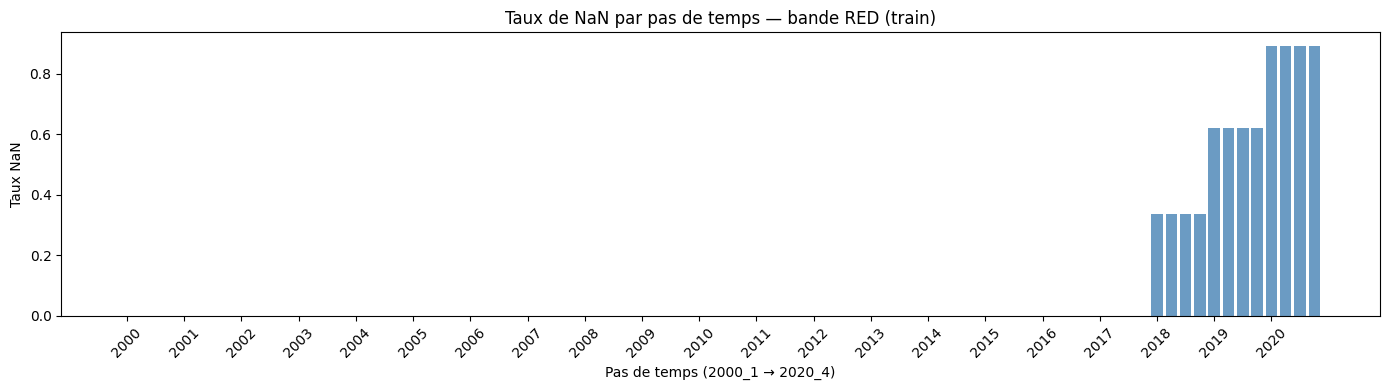

In [4]:
missing_by_step = train_bands['red'].isnull().mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(missing_by_step)), missing_by_step.values, color='steelblue', alpha=0.8)
ax.set_title('Taux de NaN par pas de temps — bande RED (train)')
ax.set_xlabel('Pas de temps (2000_1 → 2020_4)')
ax.set_ylabel('Taux NaN')
# Ajouter les étiquettes d'année tous les 4 trimestres
years = [col.split('_')[0] for col in missing_by_step.index]
ticks = [i for i, y in enumerate(years) if y != years[i-1] or i == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([years[i] for i in ticks], rotation=45)
plt.tight_layout()
plt.show()

## 3. Statistiques par bande

In [5]:
band_stats = pd.DataFrame({
    band: train_bands[band].values.flatten() for band in BANDS
})
band_stats = band_stats.dropna()
band_stats.describe().round(2)

,red,green,blue,nir,swir1,swir2
count,6815400.00,6815400.00,6815400.00,6815400.00,6815400.00,6815400.00
mean,15.07,16.09,7.96,68.70,47.78,24.82
std,11.89,10.42,9.90,18.75,13.31,9.43
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,10.00,12.00,5.00,57.00,40.00,19.00
50%,13.00,15.00,6.00,68.00,48.00,24.00
75%,17.00,17.00,8.00,80.00,56.00,29.00
max,255.00,255.00,255.00,255.00,225.00,174.00


## 4. Distribution des valeurs par bande

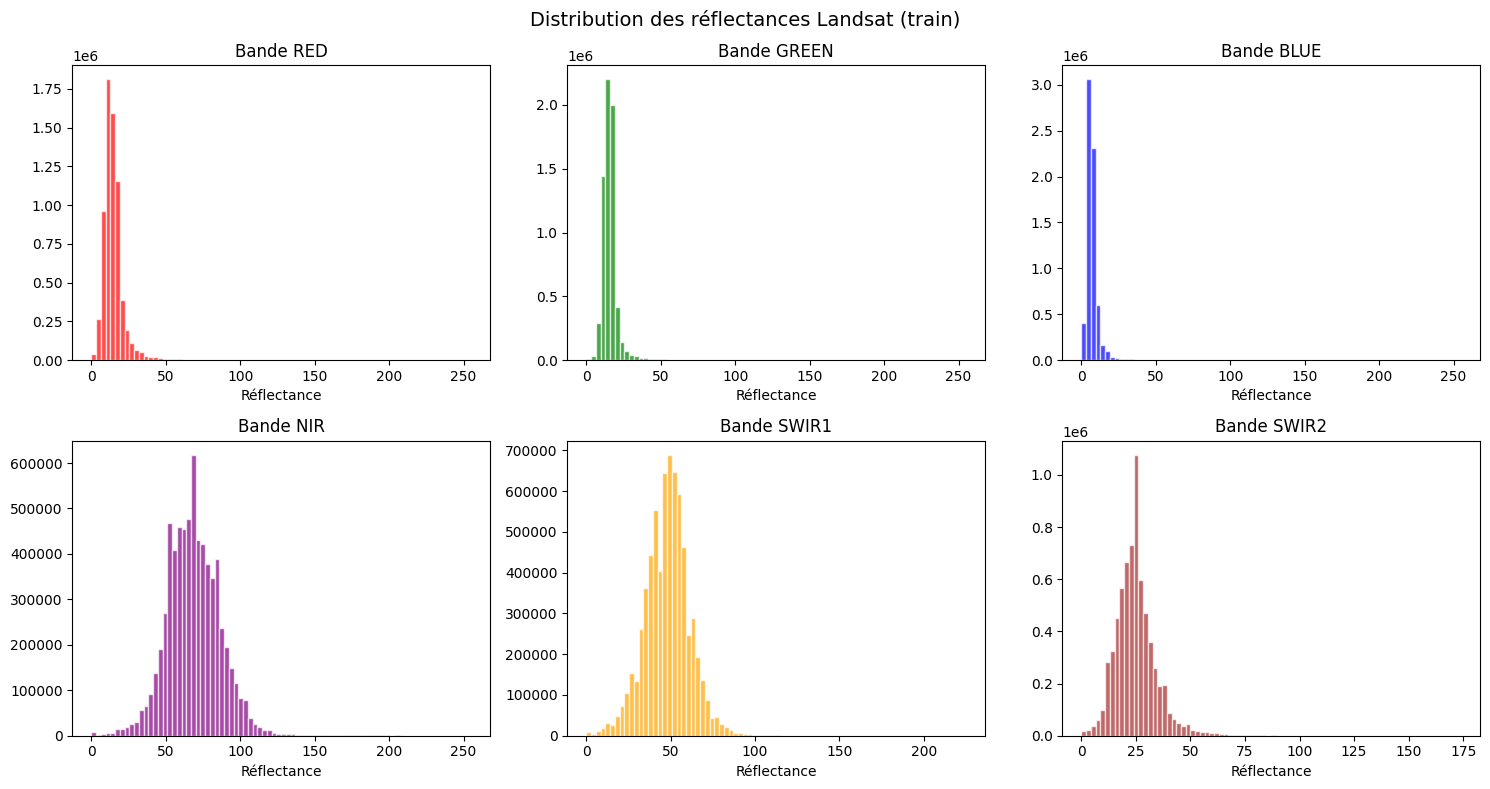

In [6]:
colors = {'red': 'red', 'green': 'green', 'blue': 'blue', 'nir': 'purple', 'swir1': 'orange', 'swir2': 'brown'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, band in enumerate(BANDS):
    vals = train_bands[band].values.flatten()
    vals = vals[~np.isnan(vals)]
    axes[i].hist(vals, bins=80, color=colors[band], alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Bande {band.upper()}')
    axes[i].set_xlabel('Réflectance')

plt.suptitle('Distribution des réflectances Landsat (train)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Profil temporel moyen par bande

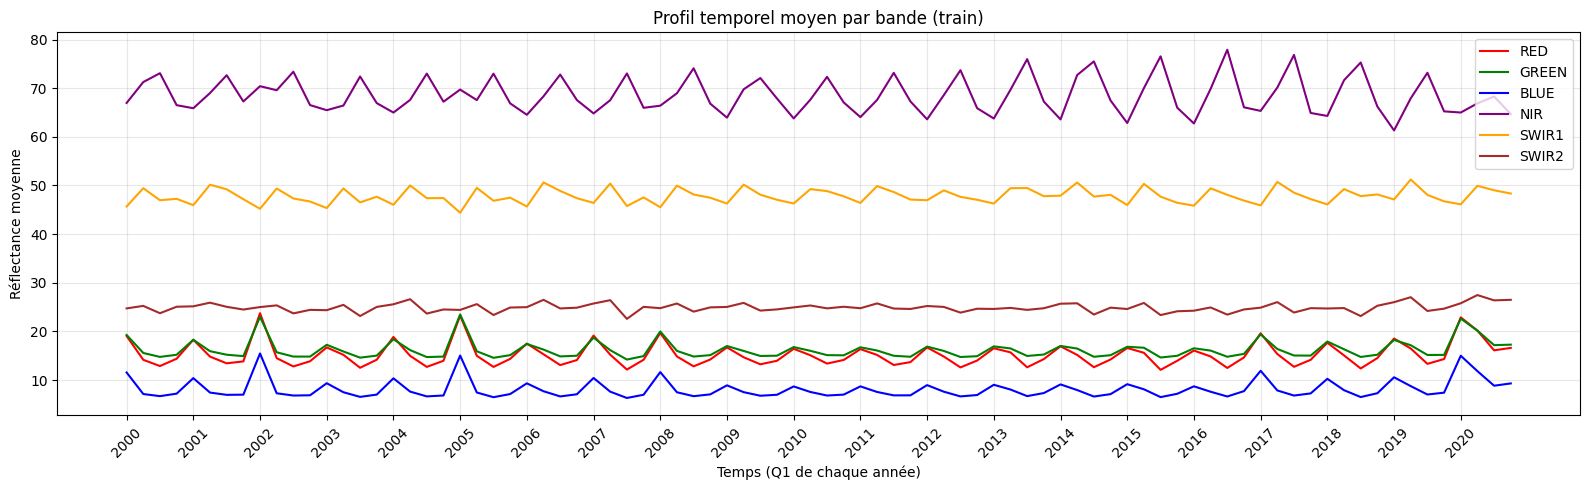

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))

for band in BANDS:
    mean_profile = train_bands[band].mean(axis=0)
    ax.plot(mean_profile.values, label=band.upper(), color=colors[band], linewidth=1.5)

# Ticks d'années
cols = train_bands['red'].columns.tolist()
year_ticks = [i for i, c in enumerate(cols) if c.endswith('_1')]
year_labels = [c.split('_')[0] for c in cols if c.endswith('_1')]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45)
ax.set_title('Profil temporel moyen par bande (train)')
ax.set_xlabel('Temps (Q1 de chaque année)')
ax.set_ylabel('Réflectance moyenne')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. NDVI moyen au fil du temps

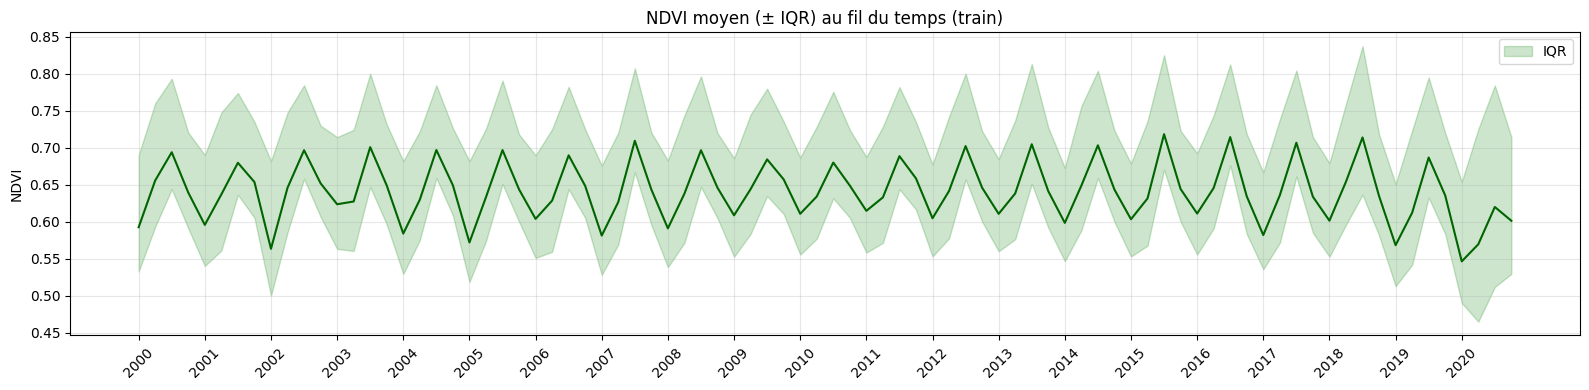

In [8]:
# NDVI = (NIR - RED) / (NIR + RED)
nir = train_bands['nir']
red = train_bands['red']

ndvi = (nir - red) / (nir + red + 1e-8)
ndvi_mean = ndvi.mean(axis=0)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ndvi_mean.values, color='darkgreen', linewidth=1.5)
ax.fill_between(range(len(ndvi_mean)),
                ndvi.quantile(0.25).values,
                ndvi.quantile(0.75).values,
                alpha=0.2, color='green', label='IQR')
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45)
ax.set_title('NDVI moyen (± IQR) au fil du temps (train)')
ax.set_ylabel('NDVI')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Exemple de série temporelle pour quelques surveys

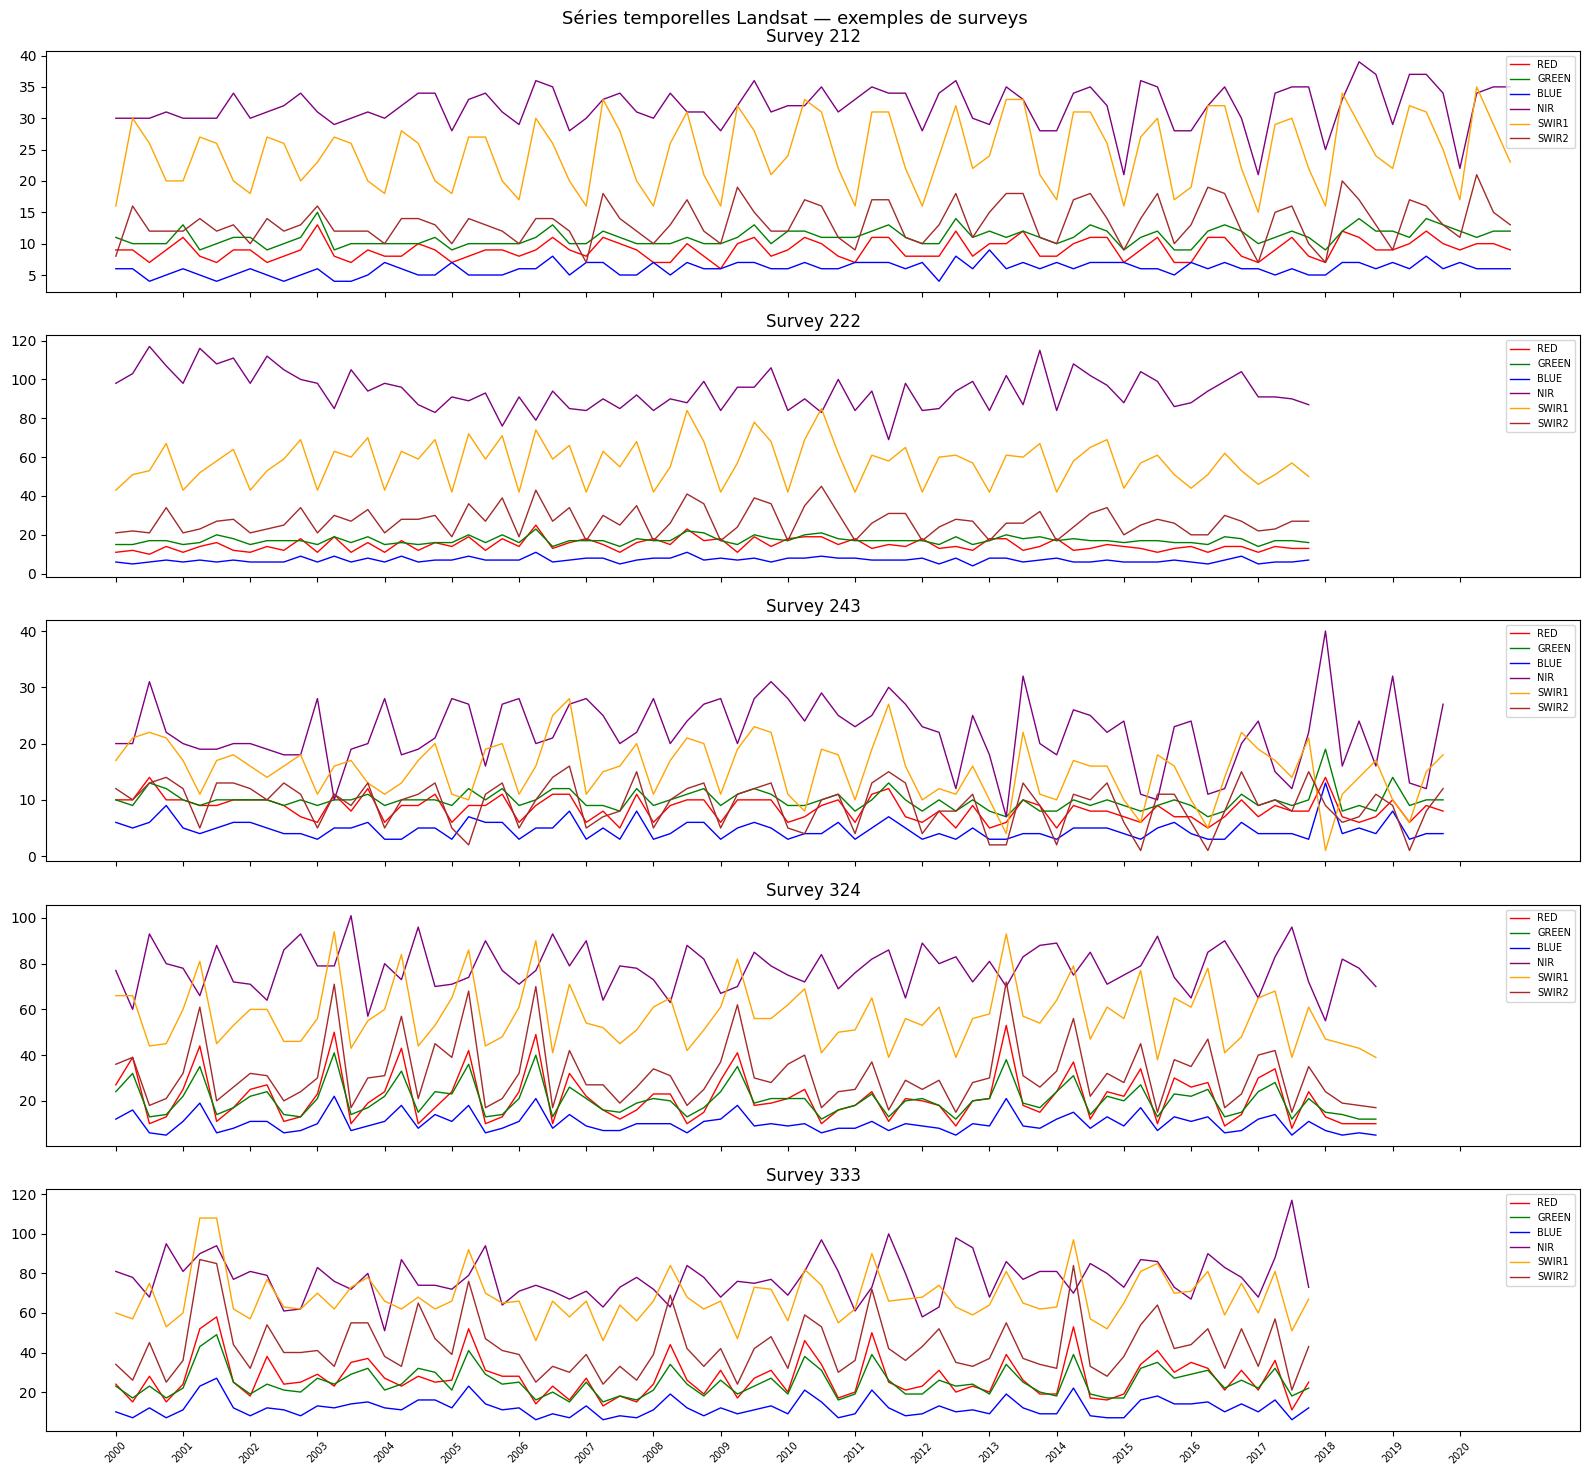

In [9]:
sample_ids = train_bands['red'].index[:5].tolist()

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(16, 3*len(sample_ids)), sharex=True)

for ax, sid in zip(axes, sample_ids):
    for band in BANDS:
        ts = train_bands[band].loc[sid]
        ax.plot(ts.values, label=band.upper(), color=colors[band], linewidth=1)
    ax.set_title(f'Survey {sid}')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, fontsize=7)

plt.suptitle('Séries temporelles Landsat — exemples de surveys', fontsize=13)
plt.tight_layout()
plt.show()